# Cooke Triplet — Chief-Ray Distortion

A classic three-element photographic objective (H. Dennis Taylor, 1893):
positive–negative–positive, stop between the second and third elements.
Prescription reconstructed from the "oslo cooke triplet example 50mm f/4
20deg" reference lens distributed with the open-source
[rayopt-notebooks](https://github.com/quartiq/rayopt-notebooks) project
(`triplet.ipynb`); glass indices (SK16, F4) are d-line (587.6 nm) values
from the SCHOTT optical glass pocket catalog. It is a textbook-scale
example, not a claim of a specific commercial lens.

The triplet's asymmetric aperture-stop position (offset toward the rear,
between the negative and rear positive elements) is the classic source of
a small but nonzero *linear* asymmetry in the object-to-image map — this
notebook measures it directly with the new chief-ray distortion metric.

In [1]:
from importlib import resources
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from raytracer.sequential import (
    FieldPoint, OpticalSystem, ParaxialModel, SequentialTracer,
    chief_ray_slope, solve_object_plane, trace_from_object,
)

CSV = resources.files("raytracer") / "data" / "cooke_triplet_prescription.csv"
system = OpticalSystem.from_prescription(CSV)
tracer = SequentialTracer(system)
conjugate = solve_object_plane(tracer)
efl = ParaxialModel(system).effective_focal_length()

print(f"{len(system)} surfaces, stop at index {system.stop_index}")
print(f"EFL = {efl:.3f} mm (design: 50 mm)")
print(f"recovered object plane z = {conjugate.object_z:.1f} mm "
      f"(a large finite stand-in for the design's object at infinity)")
print(f"magnification = {conjugate.magnification:.6f}")

7 surfaces, stop at index 4
EFL = 50.056 mm (design: 50 mm)
recovered object plane z = 13096.3 mm (a large finite stand-in for the design's object at infinity)
magnification = 0.003812


## Distortion vs. field angle

The object is effectively at infinity, so field points are parametrized
by angle rather than object height (matching how the design was
specified: "50mm f/4 20deg"). For each angle we convert to an object
height at the recovered finite conjugate, solve for the chief ray (the
ray through the center of the aperture stop) with a bracket centered on
the paraxial angle estimate, and compare its image-plane height against
the ideal `magnification * y` line — this *is* the chief-ray distortion
defined in `field_metrics`, computed here directly since `field_metrics`'s
default chief-ray search bracket is tuned for near-axis finite-conjugate
fields, not this lens's huge finite-object approximation of infinity.

The reconstruction here vignettes above roughly field angle 8-9°, which is
consistent with the "20 deg" spec being the *total* field of view (i.e.
usable to about a 10° half field) — we report up to the point where the
chief ray still clears the system.

 field (deg) |  image y (mm) |  distortion (um) | relative (ppm)
         0.0 |        0.0000 |            0.000 |            0.0
         2.0 |        1.7431 |            0.053 |           30.5
         4.0 |        3.4905 |            0.435 |          124.6
         6.0 |        5.2465 |            1.520 |          289.8
         8.0 |        7.0154 |            3.787 |          539.9


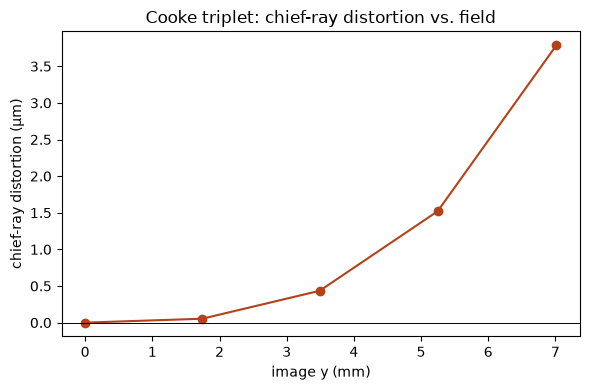

In [2]:
def chief_distortion(tracer, object_z, stop_index, magnification, angle_deg):
    if angle_deg == 0.0:
        return 0.0, 0.0, 0.0
    y = abs(object_z) * np.tan(np.deg2rad(angle_deg))
    z_stop = tracer.system.vertices[stop_index]
    estimate = -y / (z_stop - object_z)
    slope = chief_ray_slope(
        tracer, FieldPoint(y=y), stop_index=stop_index,
        bracket=(estimate - 0.02, estimate + 0.02), scan=101,
    )
    result = trace_from_object(tracer, (0.0, y), (0.0, slope))
    ideal_y = y * magnification
    distortion_um = (result.image_point[1] - ideal_y) * 1e3
    ppm = (result.image_point[1] / ideal_y - 1) * 1e6
    return y * magnification, distortion_um, ppm


FIELDS_DEG = [0.0, 2.0, 4.0, 6.0, 8.0]
rows = [chief_distortion(tracer, conjugate.object_z, system.stop_index,
                          conjugate.magnification, deg)
        for deg in FIELDS_DEG]

print(f"{'field (deg)':>12} | {'image y (mm)':>13} | {'distortion (um)':>16} | {'relative (ppm)':>14}")
for deg, (ideal_y, d_um, ppm) in zip(FIELDS_DEG, rows):
    print(f"{deg:12.1f} | {ideal_y:13.4f} | {d_um:16.3f} | {ppm:14.1f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot([r[0] for r in rows], [r[1] for r in rows], "o-", color="#b3421b")
ax.axhline(0, color="black", lw=0.7)
ax.set(xlabel="image y (mm)", ylabel="chief-ray distortion (µm)",
       title="Cooke triplet: chief-ray distortion vs. field")
fig.tight_layout()
plt.show()